# Final Mask-Level EDA Using TotalSegmentator Predicted Masks

This notebook is the clean, presentation-level mask-level EDA for the TotalSegmentator-predicted organ masks.

**Critical note:** manual ground-truth masks are not available in the current working environment. Therefore, this EDA describes **TotalSegmentator-predicted masks**, not true manual annotations. These masks are useful for exploratory analysis and pipeline development, but they must not be described as ground truth.


## 1. Setup and project paths


In [1]:
from pathlib import Path
import sys
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def find_project_root(start_path=None):
    if start_path is None:
        start_path = Path.cwd()

    start_path = Path(start_path).resolve()

    for path in [start_path] + list(start_path.parents):
        if (path / "src").exists():
            return path

    raise FileNotFoundError("Could not find project root containing src/")


project_root = find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Current working directory:", Path.cwd())
print("Project root:", project_root)
print("src exists:", (project_root / "src").exists())


Current working directory: c:\Users\P102832\Downloads\thesis_segmentation\notebooks\01_eda
Project root: C:\Users\P102832\Downloads\thesis_segmentation
src exists: True


## 2. Load configuration and define selected organs

The selected organs are the structures relevant for this EDA: spleen, kidneys, stomach, duodenum, colon, and small bowel.


In [3]:
from src.eda.totalseg_organ_level_eda import (
    SELECTED_TOTAL_MR_ORGANS,
    summarize_organs_in_folder,
    build_presence_counts,
    build_missing_organs_table,
    build_volume_stats,
    build_case_wide_summary,
    create_initial_qc_decision_table,
    apply_manual_qc_flags,
    apply_qc_to_organ_long_df,
    build_qc_filtered_volume_stats,
    build_qc_flag_counts,
    build_volume_outlier_table,
    build_missing_qc_table,
    extract_organ_mask,
    label_ids_from_string,
)

config_path = project_root / "configs" / "datasets" / "public_dataset.json"

if not config_path.exists():
    message = (
        "Missing config file: " + str(config_path) +
        ". Create this file locally with 'public_root' and 'totalseg_root'."
    )
    raise FileNotFoundError(message)

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

scan_root = Path(config["public_root"])
mask_root = Path(config["totalseg_root"])

print("scan_root exists:", scan_root.exists(), scan_root)
print("mask_root exists:", mask_root.exists(), mask_root)
print("selected organs:", SELECTED_TOTAL_MR_ORGANS)

scan_root exists: True C:\Users\P102832\Downloads\thesis_segmentation\data\raw\public_same_format\NIFTI
mask_root exists: True C:\Users\P102832\Downloads\thesis_segmentation\data\interim\public_same_format\totalsegmentator_ml
selected organs: {'spleen': [1], 'kidney_right': [2], 'kidney_left': [3], 'stomach': [6], 'small_bowel': [13], 'duodenum': [14], 'colon': [15]}


## 3. Strict scan-mask synchronization check

Before interpreting masks, every scan must have a matching mask and every mask should correspond to a scan.


In [4]:
scan_files = sorted(scan_root.glob("*.nii.gz"))
mask_files = sorted(mask_root.glob("*.nii.gz"))

scan_names = {p.name for p in scan_files}
mask_names = {p.name for p in mask_files}

missing_masks = sorted(scan_names - mask_names)
extra_masks = sorted(mask_names - scan_names)

sync_summary_df = pd.DataFrame([
    {
        "n_scans": len(scan_files),
        "n_masks": len(mask_files),
        "n_missing_masks": len(missing_masks),
        "n_extra_masks": len(extra_masks),
    }
])

missing_masks_df = pd.DataFrame({"file_name": missing_masks})
extra_masks_df = pd.DataFrame({"file_name": extra_masks})

sync_summary_df


,n_scans,n_masks,n_missing_masks,n_extra_masks
0,274,274,0,0


In [5]:
if len(missing_masks_df) > 0:
    display(missing_masks_df.head(20))
else:
    print("No missing masks.")

if len(extra_masks_df) > 0:
    display(extra_masks_df.head(20))
else:
    print("No extra masks.")


No missing masks.
No extra masks.


## 4. Build or load organ-level mask table

Set `RECOMPUTE_ORGAN_TABLES = True` if masks were regenerated or changed. Otherwise, the notebook loads the saved table when available.


In [6]:
output_dir = project_root / "metadata" / "eda" / "final_mask_level_totalseg"
output_dir.mkdir(parents=True, exist_ok=True)

organ_long_raw_path = output_dir / "organ_level_long_raw.csv"

RECOMPUTE_ORGAN_TABLES = False

if RECOMPUTE_ORGAN_TABLES or not organ_long_raw_path.exists():
    organ_long_df, mask_paths = summarize_organs_in_folder(
        mask_root=mask_root,
        selected_organs=SELECTED_TOTAL_MR_ORGANS,
    )
    organ_long_df.to_csv(organ_long_raw_path, index=False)
else:
    organ_long_df = pd.read_csv(organ_long_raw_path)
    mask_paths = mask_files

print("Number of mask files:", len(mask_paths))
print("Organ-level rows:", len(organ_long_df))
organ_long_df.head()


Number of mask files: 274
Organ-level rows: 1918


,file_name,organ_name,label_ids,present,voxel_count,volume_mm3,volume_ml,volume_ml_for_stats,fraction_of_scan_voxels,shape_x,...,best_slice,bbox_x_min,bbox_x_max,bbox_y_min,bbox_y_max,bbox_z_min,bbox_z_max,bbox_size_x,bbox_size_y,bbox_size_z
0,case101_day20.nii.gz,spleen,1,True,32740,220995.0,220.995,220.995,0.003213,266,...,77.0,46.0,109.0,110.0,183.0,56.0,84.0,64,74,29
1,case101_day20.nii.gz,kidney_right,2,True,10092,68121.0,68.121,68.121,0.000990,266,...,55.0,180.0,213.0,122.0,165.0,34.0,62.0,34,44,29
2,case101_day20.nii.gz,kidney_left,3,True,16672,112536.0,112.536,112.536,0.001636,266,...,51.0,72.0,115.0,146.0,183.0,30.0,63.0,44,38,34
3,case101_day20.nii.gz,stomach,6,True,85688,578394.0,578.394,578.394,0.008410,266,...,67.0,42.0,143.0,84.0,179.0,46.0,80.0,102,96,35
4,case101_day20.nii.gz,small_bowel,13,True,30068,202959.0,202.959,202.959,0.002951,266,...,7.0,66.0,195.0,94.0,163.0,0.0,45.0,130,70,46


## 5. Organ presence and missingness

This section checks whether each selected organ was segmented by TotalSegmentator in each scan. Missing predictions are not treated as true zero-volume anatomy.


In [7]:
presence_counts_df = build_presence_counts(organ_long_df)
missing_organs_df = build_missing_organs_table(organ_long_df)
volume_stats_df = build_volume_stats(organ_long_df)
case_wide_summary_df = build_case_wide_summary(organ_long_df)

presence_counts_df


,organ_name,n_present,n_total,n_missing,missing_fraction
0,duodenum,270,274,4,0.014599
1,colon,274,274,0,0.000000
2,kidney_left,274,274,0,0.000000
3,kidney_right,274,274,0,0.000000
4,small_bowel,274,274,0,0.000000
5,spleen,274,274,0,0.000000
6,stomach,274,274,0,0.000000


In [8]:
missing_organs_df


,file_name,organ_name,label_ids,present,voxel_count,volume_mm3,volume_ml,volume_ml_for_stats,fraction_of_scan_voxels,shape_x,...,best_slice,bbox_x_min,bbox_x_max,bbox_y_min,bbox_y_max,bbox_z_min,bbox_z_max,bbox_size_x,bbox_size_y,bbox_size_z
0,case144_day14.nii.gz,duodenum,14,False,0,0.0,0.0,NaN,0.0,266,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
1,case44_day0.nii.gz,duodenum,14,False,0,0.0,0.0,NaN,0.0,266,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
2,case78_day18.nii.gz,duodenum,14,False,0,0.0,0.0,NaN,0.0,360,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
3,case9_day22.nii.gz,duodenum,14,False,0,0.0,0.0,NaN,0.0,360,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0


## 6. Raw organ volume statistics

Raw statistics use all present predictions. Missing organ predictions are excluded from statistics by using `NaN`, not zero.


In [9]:
volume_stats_df


,organ_name,n_present,mean_ml,std_ml,min_ml,median_ml,max_ml
0,colon,274,543.688051,215.891957,119.79900,502.318125,1477.62900
1,duodenum,270,16.563370,11.997896,0.02700,13.979250,71.16525
2,kidney_left,274,124.366036,32.412584,26.91900,119.424375,247.96800
3,kidney_right,274,123.852832,34.029359,20.12850,121.678875,222.27075
4,small_bowel,274,461.287213,227.318976,51.42825,437.339250,1049.24700
5,spleen,274,595.656794,182.233820,161.75025,601.094250,1176.47775
6,stomach,274,263.102541,147.239465,27.70875,238.892625,674.80425


In [10]:
case_wide_summary_df.head()


,file_name,colon_volume_ml,duodenum_volume_ml,kidney_left_volume_ml,kidney_right_volume_ml,small_bowel_volume_ml,spleen_volume_ml,stomach_volume_ml,colon_present,duodenum_present,kidney_left_present,kidney_right_present,small_bowel_present,spleen_present,stomach_present
0,case101_day20.nii.gz,582.01200,4.53600,112.53600,68.121,202.95900,220.99500,578.3940,True,True,True,True,True,True,True
1,case101_day22.nii.gz,605.39400,5.80500,120.31200,79.461,370.11600,325.45800,512.3790,True,True,True,True,True,True,True
2,case101_day26.nii.gz,679.77900,10.85400,118.50300,86.535,463.13100,311.87700,557.4960,True,True,True,True,True,True,True
3,case101_day32.nii.gz,477.38025,13.83075,120.60225,85.671,276.74325,522.70650,550.5570,True,True,True,True,True,True,True
4,case102_day0.nii.gz,457.81875,4.72500,103.09950,97.956,160.86600,267.36075,105.2865,True,True,True,True,True,True,True


## 7. Outlier QC and manual QC decisions

The raw masks are automatic predictions. Therefore, visually suspicious outliers and missing predictions are flagged before final interpretation. Clear technical failures are excluded from volume statistics; review-only large predictions are kept unless there is strong evidence that they are invalid.


In [11]:
outlier_qc_df = build_volume_outlier_table(
    organ_long_df=organ_long_df,
    organs=list(SELECTED_TOTAL_MR_ORGANS.keys()),
    n_smallest=1,
    n_largest=1,
)

missing_qc_df = build_missing_qc_table(organ_long_df)

outlier_qc_df


,outlier_type,file_name,organ_name,label_ids,present,voxel_count,volume_ml,volume_ml_for_stats,first_slice,last_slice,n_slices_present,best_slice
0,largest,case134_day22.nii.gz,colon,15,True,218908,1477.62900,1477.62900,0.0,98.0,99,82.0
1,smallest_non_missing,case77_day20.nii.gz,colon,15,True,17748,119.79900,119.79900,0.0,52.0,42,25.0
2,largest,case107_day19.nii.gz,duodenum,14,True,10543,71.16525,71.16525,49.0,73.0,25,55.0
3,smallest_non_missing,case78_day22.nii.gz,duodenum,14,True,4,0.02700,0.02700,31.0,32.0,2,31.0
4,largest,case145_day19.nii.gz,kidney_left,3,True,36736,247.96800,247.96800,27.0,76.0,50,63.0
5,smallest_non_missing,case65_day28.nii.gz,kidney_left,3,True,3988,26.91900,26.91900,0.0,9.0,10,4.0
6,largest,case122_day27.nii.gz,kidney_right,2,True,32929,222.27075,222.27075,27.0,70.0,44,58.0
7,smallest_non_missing,case65_day28.nii.gz,kidney_right,2,True,2982,20.12850,20.12850,3.0,15.0,13,10.0
8,largest,case119_day21.nii.gz,small_bowel,13,True,155444,1049.24700,1049.24700,0.0,69.0,70,44.0
9,smallest_non_missing,case65_day28.nii.gz,small_bowel,13,True,7619,51.42825,51.42825,0.0,35.0,33,20.0


In [12]:
missing_qc_df


,file_name,organ_name,label_ids,present,voxel_count,volume_ml,first_slice,last_slice,n_slices_present,best_slice
0,case144_day14.nii.gz,duodenum,14,False,0,0.0,NaN,NaN,0,NaN
1,case44_day0.nii.gz,duodenum,14,False,0,0.0,NaN,NaN,0,NaN
2,case78_day18.nii.gz,duodenum,14,False,0,0.0,NaN,NaN,0,NaN
3,case9_day22.nii.gz,duodenum,14,False,0,0.0,NaN,NaN,0,NaN


In [13]:
qc_decision_df = create_initial_qc_decision_table(organ_long_df)
qc_decision_df = apply_manual_qc_flags(qc_decision_df)

organ_long_qc_df = apply_qc_to_organ_long_df(
    organ_long_df=organ_long_df,
    qc_df=qc_decision_df,
)

qc_filtered_volume_stats_df = build_qc_filtered_volume_stats(organ_long_qc_df)
qc_flag_counts_df = build_qc_flag_counts(qc_decision_df)

qc_decision_df[qc_decision_df["qc_flag"] != "ok"]


,file_name,organ_name,present,voxel_count,volume_ml,volume_ml_for_stats,n_slices_present,best_slice,qc_flag,qc_reason,use_for_volume_stats
255,case119_day21.nii.gz,stomach,True,99971,674.80425,674.80425,32,78.0,review_large_prediction,Largest stomach prediction.,True
256,case119_day21.nii.gz,small_bowel,True,155444,1049.24700,1049.24700,70,44.0,review_large_prediction,Largest small bowel prediction.,True
538,case134_day22.nii.gz,colon,True,218908,1477.62900,1477.62900,99,82.0,review_large_prediction,Largest colon prediction.,True
712,case144_day14.nii.gz,duodenum,False,0,0.00000,NaN,0,NaN,missing_prediction,Organ was not segmented by TotalSegmentator.,False
1025,case24_day25.nii.gz,stomach,True,4105,27.70875,27.70875,35,85.0,review_tiny_prediction,Smallest stomach prediction; likely undersegme...,False
1349,case44_day0.nii.gz,duodenum,False,0,0.00000,NaN,0,NaN,missing_prediction,Organ was not segmented by TotalSegmentator.,False
1512,case65_day0.nii.gz,spleen,True,174293,1176.47775,1176.47775,63,62.0,review_large_prediction,Largest spleen prediction; visually very large.,True
1527,case65_day28.nii.gz,kidney_right,True,2982,20.12850,20.12850,13,10.0,review_tiny_prediction,Smallest right kidney prediction; same scan ha...,False
1528,case65_day28.nii.gz,kidney_left,True,3988,26.91900,26.91900,10,4.0,review_tiny_prediction,Smallest left kidney prediction; same scan has...,False
1530,case65_day28.nii.gz,small_bowel,True,7619,51.42825,51.42825,33,20.0,review_tiny_prediction,Smallest small bowel prediction; same scan has...,False


In [14]:
qc_flag_counts_df


,organ_name,qc_flag,n
0,colon,ok,272
1,colon,review_large_prediction,1
2,colon,review_small_prediction,1
3,duodenum,exclude_near_empty_prediction,1
4,duodenum,missing_prediction,4
5,duodenum,ok,269
6,kidney_left,ok,273
7,kidney_left,review_tiny_prediction,1
8,kidney_right,ok,273
9,kidney_right,review_tiny_prediction,1


## 8. Raw versus QC-filtered statistics

This comparison checks whether a small number of failed or suspicious predictions strongly changes the dataset-level volume summaries.


In [15]:
raw_vs_qc_stats_df = volume_stats_df.merge(
    qc_filtered_volume_stats_df,
    on="organ_name",
    suffixes=("_raw", "_qc"),
)

raw_vs_qc_stats_df


,organ_name,n_present,mean_ml_raw,std_ml_raw,min_ml_raw,median_ml_raw,max_ml_raw,n_used,mean_ml_qc,std_ml_qc,min_ml_qc,median_ml_qc,max_ml_qc
0,colon,274,543.688051,215.891957,119.79900,502.318125,1477.62900,274,543.688051,215.891957,119.799000,502.318125,1477.62900
1,duodenum,270,16.563370,11.997896,0.02700,13.979250,71.16525,269,16.624843,11.977583,0.094500,13.986000,71.16525
2,kidney_left,274,124.366036,32.412584,26.91900,119.424375,247.96800,273,124.722985,31.928023,65.299500,119.461500,247.96800
3,kidney_right,274,123.852832,34.029359,20.12850,121.678875,222.27075,273,124.232775,33.504560,39.224250,121.851000,222.27075
4,small_bowel,274,461.287213,227.318976,51.42825,437.339250,1049.24700,273,462.788527,226.371471,63.685893,438.196500,1049.24700
5,spleen,274,595.656794,182.233820,161.75025,601.094250,1176.47775,274,595.656794,182.233820,161.750250,601.094250,1176.47775
6,stomach,274,263.102541,147.239465,27.70875,238.892625,674.80425,273,263.964790,146.815203,35.586000,239.692500,674.80425


## 9. Final mask-level figures

These figures are saved to `docs/figures/final_mask_level_totalseg/`.


In [16]:
figure_dir = project_root / "docs" / "figures" / "final_mask_level_totalseg"
figure_dir.mkdir(parents=True, exist_ok=True)

print("Figure directory:", figure_dir)


Figure directory: C:\Users\P102832\Downloads\thesis_segmentation\docs\figures\final_mask_level_totalseg


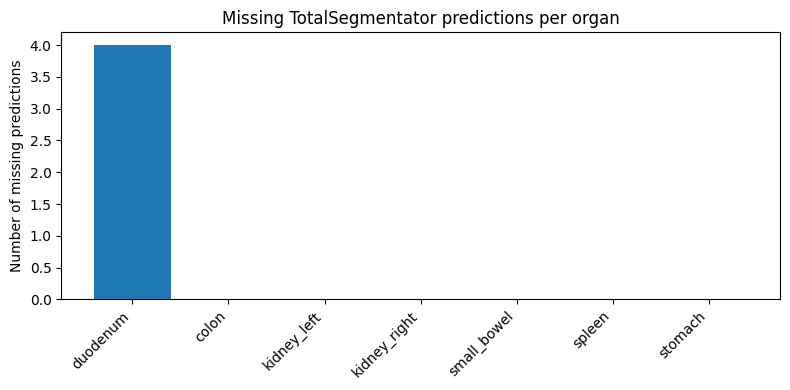

In [17]:
plt.figure(figsize=(8, 4))
plt.bar(presence_counts_df["organ_name"], presence_counts_df["n_missing"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of missing predictions")
plt.title("Missing TotalSegmentator predictions per organ")
plt.tight_layout()
plt.savefig(figure_dir / "organ_missingness.png", dpi=150)
plt.show()


<Figure size 1000x500 with 0 Axes>

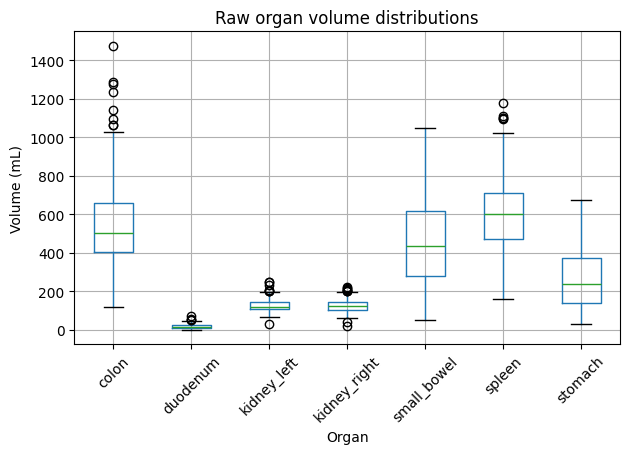

In [18]:
present_df = organ_long_df[organ_long_df["present"]].copy()

plt.figure(figsize=(10, 5))
present_df.boxplot(column="volume_ml_for_stats", by="organ_name", rot=45)
plt.suptitle("")
plt.title("Raw organ volume distributions")
plt.xlabel("Organ")
plt.ylabel("Volume (mL)")
plt.tight_layout()
plt.savefig(figure_dir / "raw_organ_volume_boxplot.png", dpi=150)
plt.show()


<Figure size 1000x500 with 0 Axes>

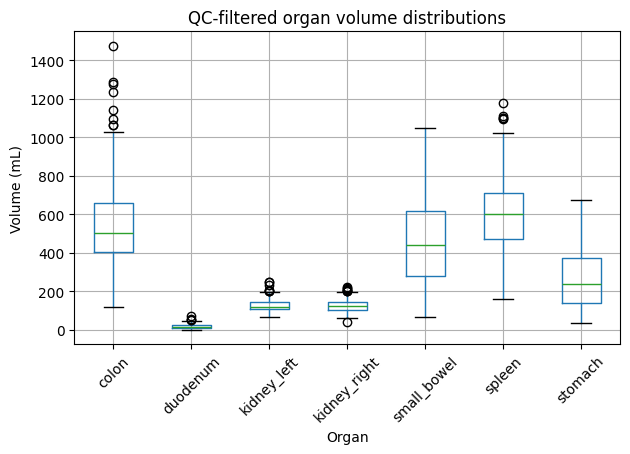

In [19]:
qc_plot_df = organ_long_qc_df[organ_long_qc_df["use_for_volume_stats"]].copy()

plt.figure(figsize=(10, 5))
qc_plot_df.boxplot(column="volume_ml_qc", by="organ_name", rot=45)
plt.suptitle("")
plt.title("QC-filtered organ volume distributions")
plt.xlabel("Organ")
plt.ylabel("Volume (mL)")
plt.tight_layout()
plt.savefig(figure_dir / "qc_organ_volume_boxplot.png", dpi=150)
plt.show()


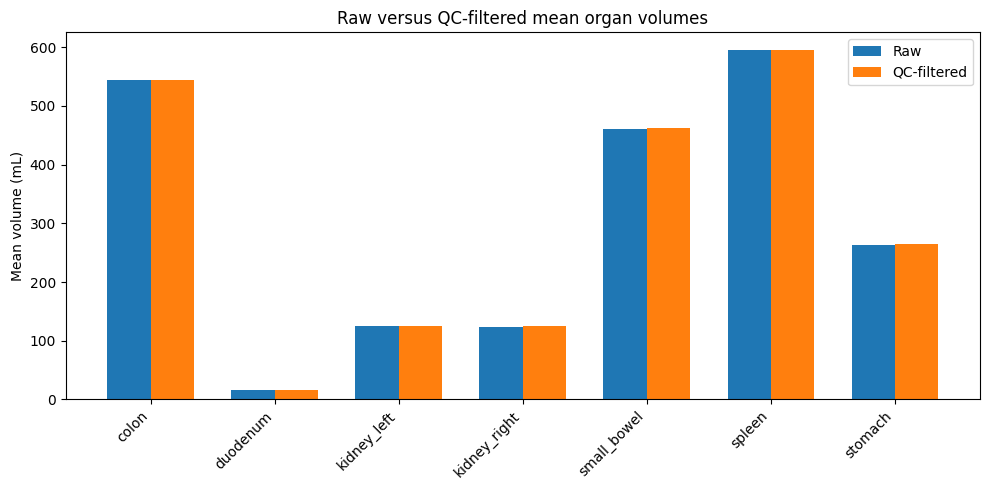

In [20]:
mean_compare_df = raw_vs_qc_stats_df[["organ_name", "mean_ml_raw", "mean_ml_qc"]].copy()
mean_compare_df = mean_compare_df.sort_values("organ_name")

x = np.arange(len(mean_compare_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width / 2, mean_compare_df["mean_ml_raw"], width, label="Raw")
plt.bar(x + width / 2, mean_compare_df["mean_ml_qc"], width, label="QC-filtered")
plt.xticks(x, mean_compare_df["organ_name"], rotation=45, ha="right")
plt.ylabel("Mean volume (mL)")
plt.title("Raw versus QC-filtered mean organ volumes")
plt.legend()
plt.tight_layout()
plt.savefig(figure_dir / "raw_vs_qc_mean_volume.png", dpi=150)
plt.show()


In [24]:
impact_df = raw_vs_qc_stats_df[
    ["organ_name", "n_present", "n_used", "mean_ml_raw", "mean_ml_qc"]
].copy()

impact_df["mean_difference_ml"] = impact_df["mean_ml_qc"] - impact_df["mean_ml_raw"]

impact_df["mean_difference_percent"] = (
    impact_df["mean_difference_ml"] / impact_df["mean_ml_raw"]
) * 100

impact_df = impact_df.sort_values("organ_name")

impact_df

,organ_name,n_present,n_used,mean_ml_raw,mean_ml_qc,mean_difference_ml,mean_difference_percent
0,colon,274,274,543.688051,543.688051,0.000000,0.000000
1,duodenum,270,269,16.563370,16.624843,0.061473,0.371141
2,kidney_left,274,273,124.366036,124.722985,0.356949,0.287015
3,kidney_right,274,273,123.852832,124.232775,0.379943,0.306769
4,small_bowel,274,273,461.287213,462.788527,1.501315,0.325462
5,spleen,274,274,595.656794,595.656794,0.000000,0.000000
6,stomach,274,273,263.102541,263.964790,0.862248,0.327723


## 10. Optional visual QC overlay regeneration

This section is optional. It can regenerate individual outlier overlays, but it loads scans and masks, so it may take time. Keep `GENERATE_OUTLIER_OVERLAYS = False` unless you want to recreate these figures.


In [21]:
GENERATE_OUTLIER_OVERLAYS = False

if GENERATE_OUTLIER_OVERLAYS:
    from src.eda.visualize_masks import load_nifti, show_nifti_overlay_from_arrays
    from src.eda.mask_level_eda import load_multilabel_mask

    overlay_dir = figure_dir / "outlier_overlays"
    overlay_dir.mkdir(parents=True, exist_ok=True)

    for _, row in outlier_qc_df.iterrows():
        if not bool(row["present"]):
            continue

        file_name = row["file_name"]
        organ_name = row["organ_name"]
        label_ids = label_ids_from_string(row["label_ids"])
        best_slice = int(row["best_slice"])

        scan_path = scan_root / file_name
        mask_path = mask_root / file_name

        scan_volume, _ = load_nifti(scan_path)
        mask_volume, _, _ = load_multilabel_mask(mask_path)
        organ_mask = extract_organ_mask(mask_volume, label_ids)

        save_path = overlay_dir / f"{file_name.replace('.nii.gz', '')}_{organ_name}_{row['outlier_type']}.png"

        show_nifti_overlay_from_arrays(
            scan_volume=scan_volume,
            mask_volume=organ_mask,
            axis=2,
            slice_idx=best_slice,
            title=f"{file_name} | {organ_name} | {row['outlier_type']} | slice {best_slice}",
            save_path=save_path,
        )

    print("Saved overlays to:", overlay_dir)
else:
    print("Skipping outlier overlay regeneration. Set GENERATE_OUTLIER_OVERLAYS=True to run it.")


Skipping outlier overlay regeneration. Set GENERATE_OUTLIER_OVERLAYS=True to run it.


## 11. Save final mask-level EDA outputs


In [22]:
sync_summary_df.to_csv(output_dir / "scan_mask_sync_summary.csv", index=False)
missing_masks_df.to_csv(output_dir / "missing_masks.csv", index=False)
extra_masks_df.to_csv(output_dir / "extra_masks.csv", index=False)

organ_long_df.to_csv(output_dir / "organ_level_long_raw.csv", index=False)
presence_counts_df.to_csv(output_dir / "organ_presence_counts.csv", index=False)
missing_organs_df.to_csv(output_dir / "missing_organs_table.csv", index=False)
volume_stats_df.to_csv(output_dir / "organ_volume_stats_raw.csv", index=False)
case_wide_summary_df.to_csv(output_dir / "case_wide_organ_summary_raw.csv", index=False)

outlier_qc_df.to_csv(output_dir / "volume_outlier_qc_cases.csv", index=False)
missing_qc_df.to_csv(output_dir / "missing_organ_qc_cases.csv", index=False)
qc_decision_df.to_csv(output_dir / "qc_decision_table.csv", index=False)
qc_flag_counts_df.to_csv(output_dir / "qc_flag_counts.csv", index=False)
organ_long_qc_df.to_csv(output_dir / "organ_level_long_qc.csv", index=False)
qc_filtered_volume_stats_df.to_csv(output_dir / "organ_volume_stats_qc.csv", index=False)
raw_vs_qc_stats_df.to_csv(output_dir / "raw_vs_qc_volume_stats.csv", index=False)

print("Saved final mask-level EDA tables to:", output_dir)


Saved final mask-level EDA tables to: C:\Users\P102832\Downloads\thesis_segmentation\metadata\eda\final_mask_level_totalseg


## 12. Report-ready interpretation

Use this generated text as the basis for the thesis/report interpretation. Edit the wording only after checking the final numbers.


In [23]:
n_files = organ_long_df["file_name"].nunique()
n_organs = organ_long_df["organ_name"].nunique()
total_missing = int((~organ_long_df["present"]).sum())

missing_summary = presence_counts_df[presence_counts_df["n_missing"] > 0][["organ_name", "n_missing", "n_total"]]
excluded_count = int((~qc_decision_df["use_for_volume_stats"]).sum())

mask_interpretation = f"""
Mask-level EDA summary:
TotalSegmentator-predicted masks were evaluated for {n_files} scans and {n_organs} selected organs. 
The scan-mask synchronization check found {int(sync_summary_df.loc[0, 'n_missing_masks'])} missing masks and {int(sync_summary_df.loc[0, 'n_extra_masks'])} extra masks. 
The organ presence check found {total_missing} missing organ predictions. Missing predictions were treated as missing model outputs, not as true zero-volume anatomy. 
After visual outlier QC, {excluded_count} file-organ entries were excluded from volume statistics. 
The raw and QC-filtered summary statistics should be reported together to show that QC decisions were transparent and did not silently alter the analysis.
"""

print(mask_interpretation)
print("Organs with missing predictions:")
display(missing_summary)



Mask-level EDA summary:
TotalSegmentator-predicted masks were evaluated for 274 scans and 7 selected organs. 
The scan-mask synchronization check found 0 missing masks and 0 extra masks. 
The organ presence check found 4 missing organ predictions. Missing predictions were treated as missing model outputs, not as true zero-volume anatomy. 
After visual outlier QC, 9 file-organ entries were excluded from volume statistics. 
The raw and QC-filtered summary statistics should be reported together to show that QC decisions were transparent and did not silently alter the analysis.

Organs with missing predictions:


,organ_name,n_missing,n_total
0,duodenum,4,274


## Final mask-level EDA conclusion

The mask-level EDA confirms that the TotalSegmentator-predicted masks are available for the final scan set and that selected organ masks can be summarized at dataset level. Missing predictions and visually suspicious outliers are explicitly flagged. The final interpretation should use the QC-filtered statistics while still reporting the raw statistics and QC decisions for transparency.
